# EDA — Precios de Propiedades Miami / Sur de Florida

Objetivo: entender la distribución del target, los features más relevantes y los patrones geográficos antes de modelar.

In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

train = pd.read_csv('../data/tabular/train_processed.csv')
test  = pd.read_csv('../data/tabular/test_processed.csv')

print(f'Train: {train.shape}  |  Test: {test.shape}')

Train: (11840, 46)  |  Test: (5038, 44)


## 0. Perfil automático (sweetviz)

Genera un reporte HTML interactivo con distribuciones, missing values, correlaciones y outliers para todas las columnas. Se generan dos reportes:
- **Train solo** — con análisis por valor del target
- **Train vs Test** — detecta si las distribuciones difieren (distributional shift)

In [ ]:
import sweetviz as sv

# Perfil del train con análisis por target
report_train = sv.analyze(train, target_feat='lastSoldPrice_hpi_adjusted')
report_train.show_html('../reports/eda_sweetviz_train.html', open_browser=False)
print("Reporte guardado: reports/eda_sweetviz_train.html")

In [ ]:
# Comparación train vs test — detecta distributional shift entre conjuntos
# Las columnas que no están en test (target + leaky) se excluyen automáticamente
report_cmp = sv.compare(
    [train, "Train"],
    [test,  "Test"],
    target_feat='lastSoldPrice_hpi_adjusted'
)
report_cmp.show_html('../reports/eda_sweetviz_compare.html', open_browser=False)
print("Reporte comparativo guardado: reports/eda_sweetviz_compare.html")

## 1. Resumen general

In [5]:
train.describe(include='all').T[['count','mean','std','min','50%','max']]

,count,mean,std,min,50%,max
zpid,11840.0,1008799.169679,5070.50878,1000001.0,1008753.5,1017606.0
lastSoldPrice_hpi_adjusted,11840.0,559019.362237,350971.426392,51275.851673,472289.030264,1986843.236497
log_price,11840.0,13.032547,0.663308,10.844995,13.065349,14.502058
description,11840,NaN,NaN,NaN,NaN,NaN
bedrooms,11360.0,2.446743,1.047838,0.0,2.0,11.0
bathrooms,11615.0,1.97325,0.752093,0.0,2.0,10.0
livingArea,11668.0,1417.349417,669.386605,0.0,1311.0,25163.0
yearBuilt,11529.0,1975.436204,21.475135,1900.0,1973.0,2027.0
latitude,11809.0,26.037538,0.38874,25.506687,25.90254,30.562725
longitude,11809.0,-80.179653,0.135932,-85.63624,-80.16241,-80.034134


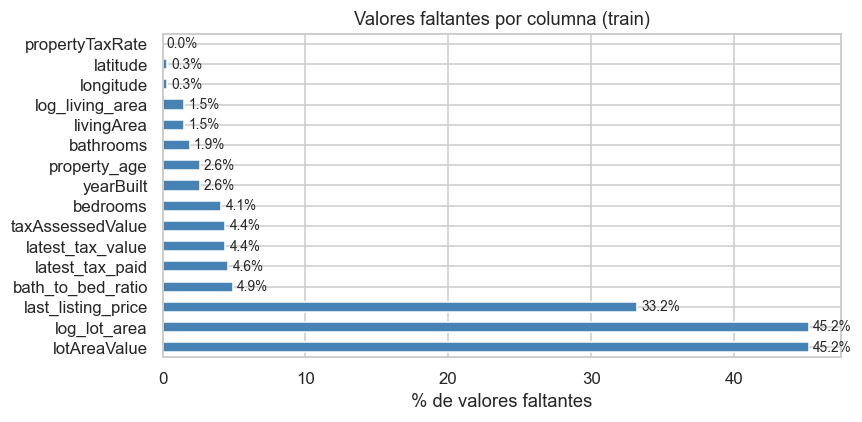

In [6]:
# Valores faltantes
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
missing_pct.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('% de valores faltantes')
ax.set_title('Valores faltantes por columna (train)')
for i, v in enumerate(missing_pct):
    ax.text(v + 0.3, i, f'{v}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 1b. Ceros como valores faltantes

Varias columnas usan `0` para indicar "dato no disponible" en lugar de `NaN`.
Esto es habitual en datasets de scraping inmobiliario donde el campo no se completó.

| Columna | Ceros sospechosos | Motivo |
|---|---|---|
| `bathrooms` | 75 (0.6%) | Ninguna propiedad real tiene 0 baños (excepto terrenos) |
| `livingArea` | 7 (0.1%) | Área habitable 0 ft² es imposible |
| `bedrooms` | 96 (0.8%) | 0 válido solo en studios (CONDO/APARTMENT) |

**Estrategia:** convertir ceros inválidos a `NaN` → imputar con mediana por `homeType` (convención del proyecto).

In [ ]:
# ── Diagnóstico: ceros que son datos faltantes ──────────────────────────────
CERO_ES_MISSING = ['bathrooms', 'livingArea', 'bedrooms']

rows = []
for col in CERO_ES_MISSING:
    nulos  = train[col].isna().sum()
    ceros  = (train[col] == 0).sum()
    total  = nulos + ceros
    rows.append({
        'columna': col,
        'NaN reales': nulos,
        'Ceros sospechosos': ceros,
        'Missing TOTAL': total,
        'Missing TOTAL %': f'{total/len(train)*100:.1f}%',
        'Mediana real (>0)': round(train[col][train[col] > 0].median(), 1)
    })

pd.DataFrame(rows).set_index('columna')

In [ ]:
# ── Corrección + imputación ──────────────────────────────────────────────────
train_clean = train.copy()

# bathrooms: 0 es missing salvo en LOT (terreno sin construcción)
mask_bath = (train_clean['bathrooms'] == 0) & (train_clean['homeType'] != 'LOT')
train_clean.loc[mask_bath, 'bathrooms'] = np.nan

# livingArea: 0 siempre es missing
train_clean['livingArea'] = train_clean['livingArea'].replace(0, np.nan)

# bedrooms: 0 válido solo en CONDO/APARTMENT (studios); el resto es missing
mask_bed = (train_clean['bedrooms'] == 0) & \
           (~train_clean['homeType'].isin(['CONDO', 'APARTMENT']))
train_clean.loc[mask_bed, 'bedrooms'] = np.nan

# Imputar con mediana por homeType, fallback a mediana global
for col in ['bathrooms', 'livingArea', 'bedrooms']:
    global_med = train_clean[col].median()
    for ht, grp in train_clean.groupby('homeType'):
        med = grp[col].median()
        med = med if not np.isnan(med) else global_med
        mask = (train_clean['homeType'] == ht) & train_clean[col].isna()
        train_clean.loc[mask, col] = med

# Verificar: no deben quedar nulos en esas columnas
assert train_clean[['bathrooms', 'livingArea', 'bedrooms']].isna().sum().sum() == 0

# ── Visualización: antes vs después ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, col in zip(axes, ['bathrooms', 'livingArea', 'bedrooms']):
    before = train[col][train[col] > 0].dropna()
    after  = train_clean[col]
    p99 = after.quantile(0.99)
    ax.hist(before, bins=30, alpha=0.6, label=f'Original (sin ceros)\nn={len(before):,}',
            color='steelblue', edgecolor='white')
    ax.hist(after,  bins=30, alpha=0.5, label=f'Corregido + imputado\nn={len(after):,}',
            color='darkorange', edgecolor='white')
    ax.set_xlim(0, p99)
    ax.set_title(col, fontsize=12)
    ax.legend(fontsize=8)

plt.suptitle('Efecto de reemplazar ceros-como-NaN + imputación por mediana de homeType',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

# Medianas de imputación por tipo de propiedad
print("\nMedianas usadas para imputación (por homeType):")
imp = train_clean.groupby('homeType')[['bathrooms', 'livingArea', 'bedrooms']].median()
print(imp.to_string())

## 2. Distribución del target

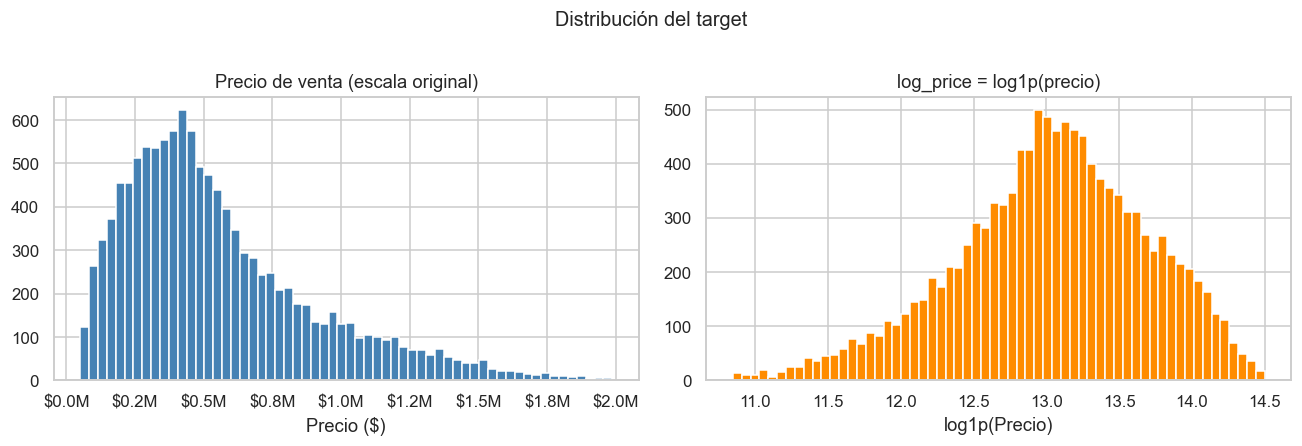

count       $11,840
mean       $559,019
std        $350,971
min         $51,276
25%        $303,966
50%        $472,289
75%        $729,278
max      $1,986,843
Name: lastSoldPrice_hpi_adjusted, dtype: str


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Escala original
axes[0].hist(train['lastSoldPrice_hpi_adjusted'], bins=60, color='steelblue', edgecolor='white')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[0].set_title('Precio de venta (escala original)')
axes[0].set_xlabel('Precio ($)')

# Escala log
axes[1].hist(train['log_price'], bins=60, color='darkorange', edgecolor='white')
axes[1].set_title('log_price = log1p(precio)')
axes[1].set_xlabel('log1p(Precio)')

plt.suptitle('Distribución del target', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(train['lastSoldPrice_hpi_adjusted'].describe().apply(lambda x: f'${x:,.0f}'))

## 3. Tipo de propiedad

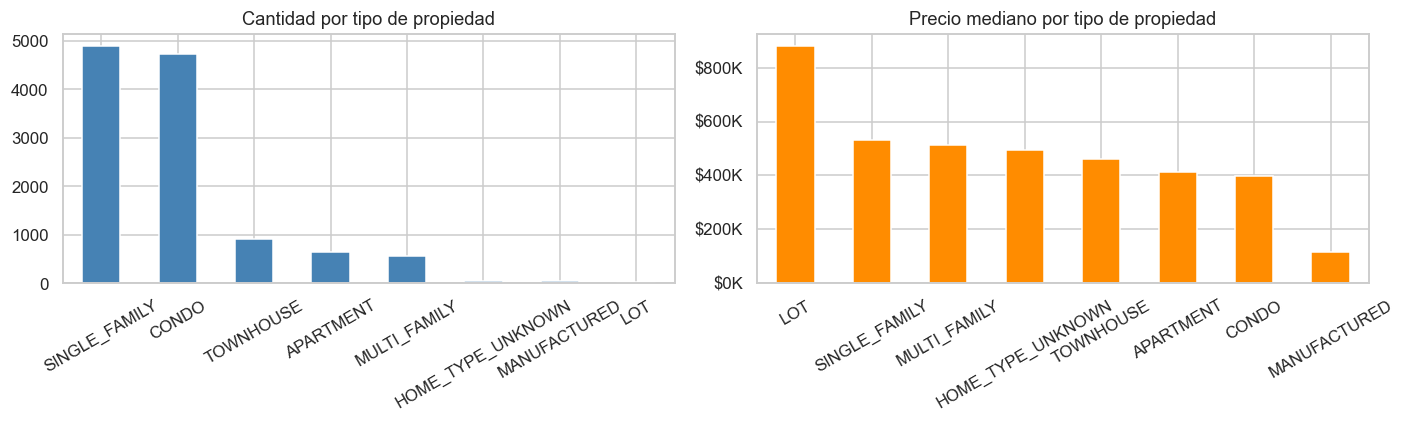

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Conteo
counts = train['homeType'].value_counts()
counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Cantidad por tipo de propiedad')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

# Precio mediano
medians = train.groupby('homeType')['lastSoldPrice_hpi_adjusted'].median().sort_values(ascending=False)
medians.plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
axes[1].set_title('Precio mediano por tipo de propiedad')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 4. Features numéricos clave

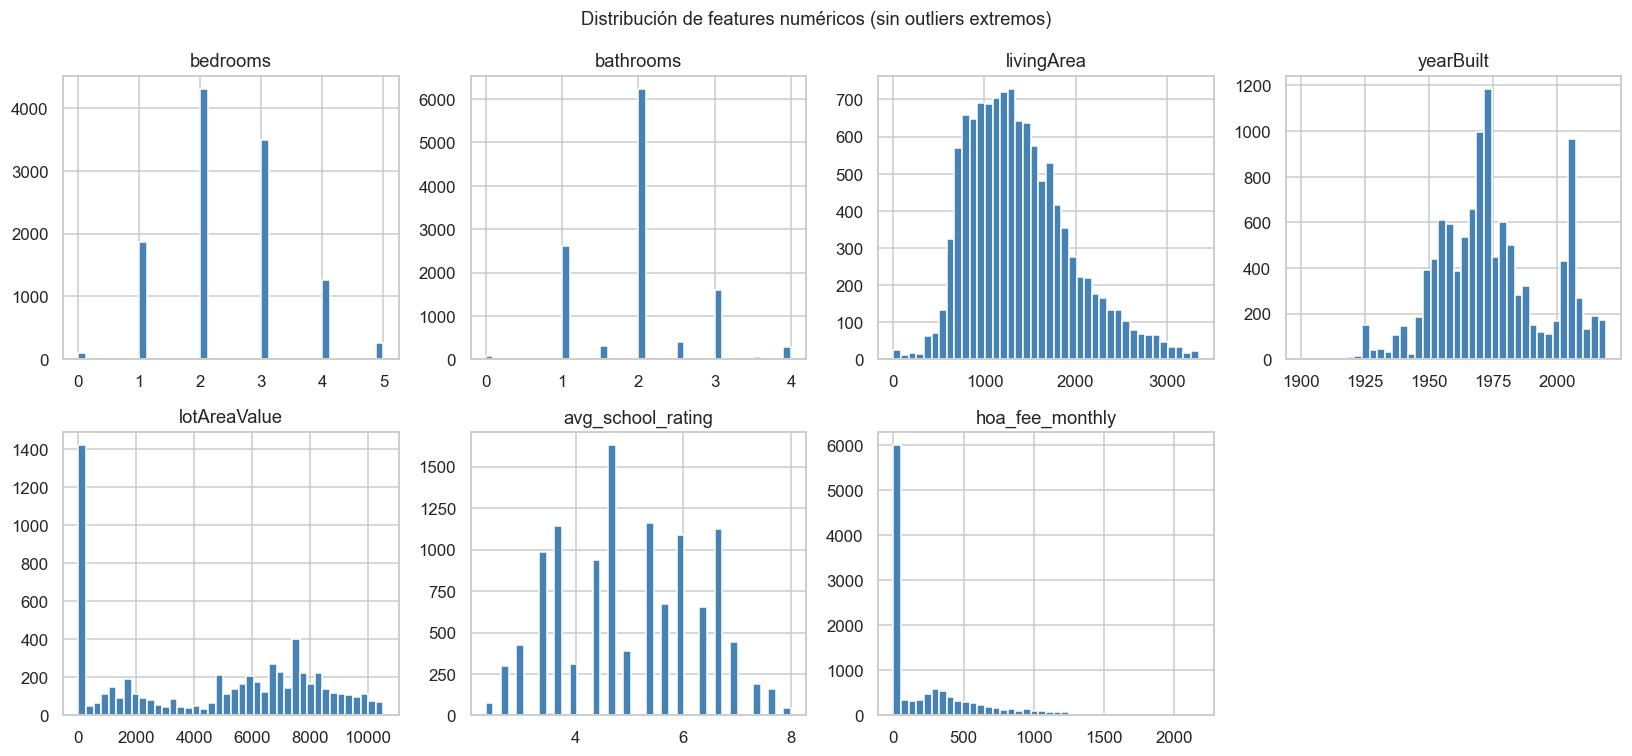

In [9]:
num_features = ['bedrooms', 'bathrooms', 'livingArea', 'yearBuilt', 
                'lotAreaValue', 'avg_school_rating', 'hoa_fee_monthly']

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
axes = axes.flatten()

for i, col in enumerate(num_features):
    data = train[col].dropna()
    # Limitar outliers extremos para visualización
    p99 = data.quantile(0.99)
    data = data[data <= p99]
    axes[i].hist(data, bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

axes[-1].set_visible(False)
plt.suptitle('Distribución de features numéricos (sin outliers extremos)', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Correlación con el precio

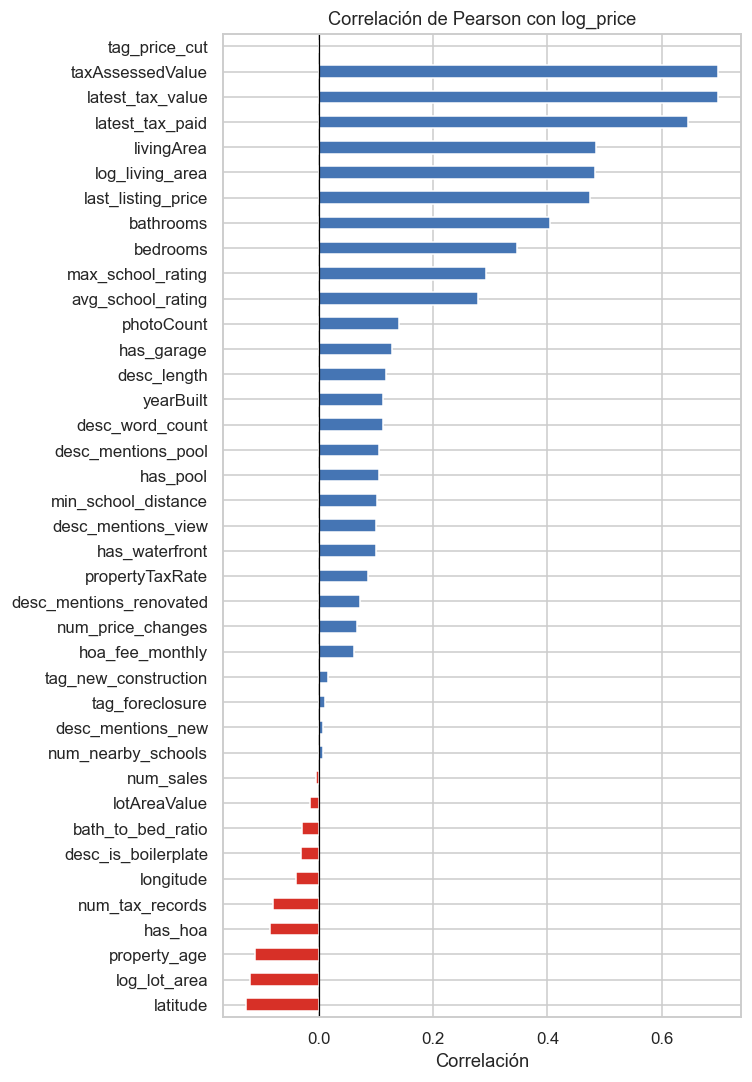

In [10]:
exclude = ['zpid', 'lastSoldPrice_hpi_adjusted', 'log_price', 'zipcode', 'zip_3digit']
num_cols = train.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c not in exclude]

corr = train[num_cols + ['log_price']].corr()['log_price'].drop('log_price').sort_values()

colors = ['#d73027' if v < 0 else '#4575b4' for v in corr]

fig, ax = plt.subplots(figsize=(7, 10))
corr.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación de Pearson con log_price', fontsize=12)
ax.set_xlabel('Correlación')
plt.tight_layout()
plt.show()

## 6. Scatter: área habitable vs precio

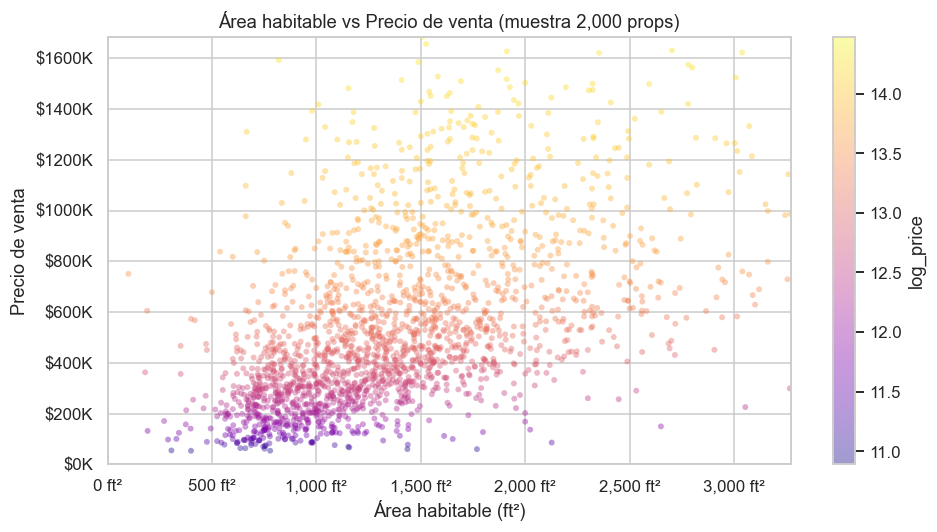

In [11]:
sample = train.dropna(subset=['livingArea']).sample(2000, random_state=42)

fig, ax = plt.subplots(figsize=(9, 5))
scatter = ax.scatter(
    sample['livingArea'],
    sample['lastSoldPrice_hpi_adjusted'],
    c=sample['log_price'], cmap='plasma',
    alpha=0.4, s=15, linewidths=0
)
ax.set_xlim(0, sample['livingArea'].quantile(0.99))
ax.set_ylim(0, sample['lastSoldPrice_hpi_adjusted'].quantile(0.99))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f} ft²'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.set_xlabel('Área habitable (ft²)')
ax.set_ylabel('Precio de venta')
ax.set_title('Área habitable vs Precio de venta (muestra 2,000 props)')
plt.colorbar(scatter, ax=ax, label='log_price')
plt.tight_layout()
plt.show()

## 7. Precio por número de habitaciones y baños

C:\Users\SBI\AppData\Local\Temp\ipykernel_10448\3704987412.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=[str(int(v)) for v in order],
C:\Users\SBI\AppData\Local\Temp\ipykernel_10448\3704987412.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=[str(int(v)) for v in order],


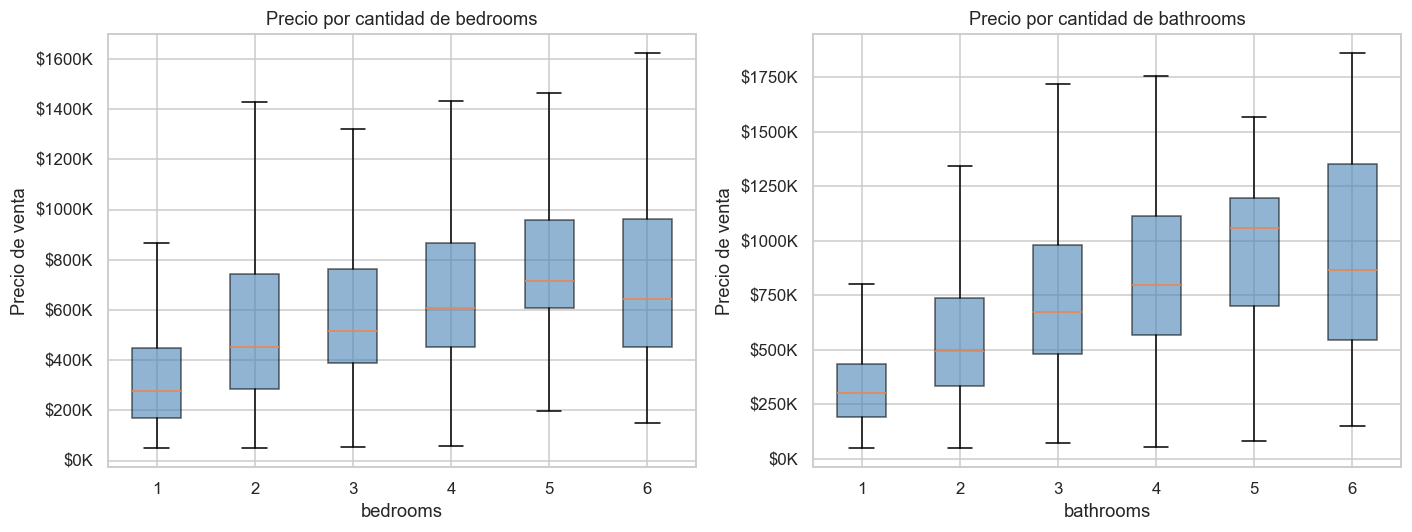

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col in zip(axes, ['bedrooms', 'bathrooms']):
    data = train[train[col].between(1, 6)].copy()
    data[col] = data[col].round(0)  # agrupar medios baños
    order = sorted(data[col].unique())
    groups = [data[data[col] == v]['lastSoldPrice_hpi_adjusted'].values for v in order]
    bp = ax.boxplot(groups, labels=[str(int(v)) for v in order],
                    patch_artist=True, showfliers=False,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
    ax.set_xlabel(col)
    ax.set_ylabel('Precio de venta')
    ax.set_title(f'Precio por cantidad de {col}')

plt.tight_layout()
plt.show()

## 8. Mapa geográfico de precios

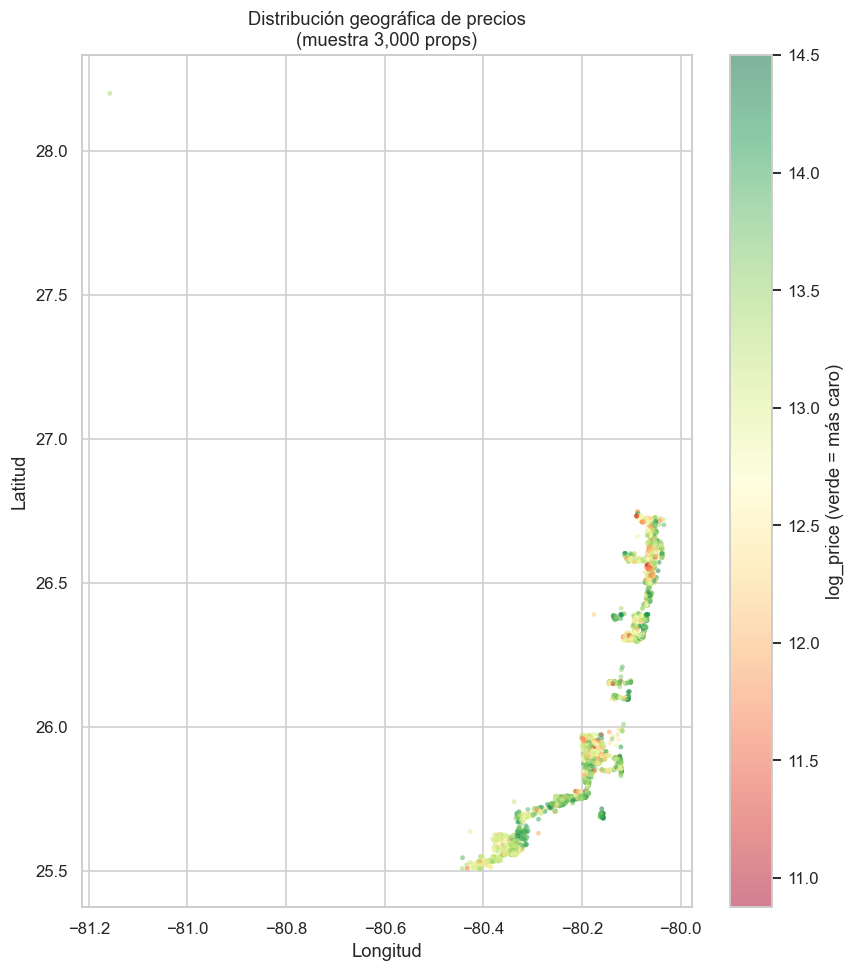

In [13]:
sample_geo = train.dropna(subset=['latitude', 'longitude']).sample(3000, random_state=42)

fig, ax = plt.subplots(figsize=(8, 9))
sc = ax.scatter(
    sample_geo['longitude'],
    sample_geo['latitude'],
    c=sample_geo['log_price'],
    cmap='RdYlGn', alpha=0.5, s=10, linewidths=0
)
plt.colorbar(sc, ax=ax, label='log_price (verde = más caro)')
ax.set_title('Distribución geográfica de precios\n(muestra 3,000 props)', fontsize=12)
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
plt.tight_layout()
plt.show()

## 9. Features booleanos: impacto en precio

In [ ]:
bool_cols = ['has_pool', 'has_garage', 'has_waterfront', 'has_hoa',
             'tag_new_construction', 'tag_foreclosure', 'tag_price_cut']

results = []
for col in bool_cols:
    yes = train[train[col] == 1]['lastSoldPrice_hpi_adjusted'].median()
    no  = train[train[col] == 0]['lastSoldPrice_hpi_adjusted'].median()
    results.append({'feature': col, 'Con (mediana)': yes, 'Sin (mediana)': no,
                    'Diferencia %': round((yes - no) / no * 100, 1)})

df_bool = pd.DataFrame(results).set_index('feature')
df_bool[['Con (mediana)', 'Sin (mediana)']] = df_bool[['Con (mediana)', 'Sin (mediana)']].applymap(lambda x: f'${x:,.0f}')
df_bool

In [ ]:
diffs = []
for col in bool_cols:
    yes = train[train[col] == 1]['lastSoldPrice_hpi_adjusted'].median()
    no  = train[train[col] == 0]['lastSoldPrice_hpi_adjusted'].median()
    diffs.append((col, round((yes - no) / no * 100, 1)))

df_diff = pd.DataFrame(diffs, columns=['feature', 'diff_pct']).sort_values('diff_pct')
colors = ['#d73027' if v < 0 else '#4575b4' for v in df_diff['diff_pct']]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(df_diff['feature'], df_diff['diff_pct'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Diferencia % en precio mediano (con vs sin)')
ax.set_title('Impacto de features booleanos en el precio mediano')
plt.tight_layout()
plt.show()

## 10. Heatmap de correlaciones entre features numéricos

## 13. Feature Engineering — nuevos features potenciales

Los features de Ronda 2 ya cubren: ratios de impuestos, scores de lujo/distress, interacciones numéricas y agregaciones por ZIP.

Esta sección explora **7 features nuevos** que complementan lo existente:

| Feature | Fórmula | Por qué es útil |
|---|---|---|
| `price_per_sqft` | `precio / livingArea` | Métrica estándar de real estate; normaliza tamaño |
| `market_premium` | `precio / taxAssessedValue` | Captura si el mercado paga más o menos que el catastro |
| `listing_discount_pct` | `(listing − precio) / listing` | Dinámica de negociación; ventas distressed = descuento alto |
| `area_per_room` | `livingArea / (beds + baths)` | Eficiencia de espacio; diferencia estudios de familias grandes |
| `renovation_x_age` | `desc_mentions_renovated × property_age` | Propiedades viejas pero renovadas: señal de upgrade de valor |
| `photo_signal` | `photoCount / median(photoCount por homeType)` | Esfuerzo de marketing relativo; atípicamente alto/bajo |
| `hoa_burden` | `(hoa_fee_monthly × 12) / precio` | Costo de mantenimiento como % del valor — relevante para CONDOs |

In [ ]:
# ── Construir features nuevos ────────────────────────────────────────────────
fe = train_clean.copy()

fe['price_per_sqft'] = fe['lastSoldPrice_hpi_adjusted'] / fe['livingArea']

fe['market_premium'] = fe['lastSoldPrice_hpi_adjusted'] / fe['taxAssessedValue'].replace(0, np.nan)

fe['listing_discount_pct'] = (
    (fe['last_listing_price'] - fe['lastSoldPrice_hpi_adjusted']) / fe['last_listing_price']
)

fe['area_per_room'] = fe['livingArea'] / (fe['bedrooms'] + fe['bathrooms']).replace(0, np.nan)

fe['renovation_x_age'] = fe['desc_mentions_renovated'] * fe['property_age']

photo_med = fe.groupby('homeType')['photoCount'].transform('median').replace(0, np.nan)
fe['photo_signal'] = fe['photoCount'] / photo_med

fe['hoa_burden'] = (fe['hoa_fee_monthly'] * 12) / fe['lastSoldPrice_hpi_adjusted']

# ── Correlación de todos los nuevos features con log_price ───────────────────
NEW_FEATS = ['price_per_sqft', 'market_premium', 'listing_discount_pct',
             'area_per_room', 'renovation_x_age', 'photo_signal', 'hoa_burden']

# También incluir round2 para comparar
ROUND2_FEATS = ['tax_per_sqft', 'listing_to_tax_ratio', 'luxury_score',
                'distress_score', 'school_x_area', 'beds_x_baths']

# Calcular round2 features en fe para comparar (no están en train_clean)
fe['tax_per_sqft']         = fe['taxAssessedValue'] / (fe['livingArea'] + 1)
fe['listing_to_tax_ratio'] = fe['last_listing_price'] / (fe['taxAssessedValue'] + 1)
fe['luxury_score']         = (fe['has_pool'] + fe['has_waterfront'] + fe['has_garage'] +
                               (fe['hoa_fee_monthly'] > 200).astype(int))
fe['distress_score']       = (fe['tag_foreclosure'] + fe['tag_price_cut'] +
                               (fe['num_price_changes'] > 2).astype(int))
fe['school_x_area']        = fe['avg_school_rating'] * fe['log_living_area']
fe['beds_x_baths']         = fe['bedrooms'] * fe['bathrooms']

all_feats = NEW_FEATS + ROUND2_FEATS
corr = fe[all_feats + ['log_price']].corr()['log_price'].drop('log_price').sort_values()

colors = ['#BF0A30' if f in NEW_FEATS else '#8B6530' for f in corr.index]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(corr.index, corr.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlación de Pearson con log_price', fontsize=11)
ax.set_title('Correlación con el precio\nRojo = features nuevos  |  Marrón = features Round 2', fontsize=11)
for bar, val in zip(bars, corr.values):
    ax.text(val + (0.005 if val >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# ── Zoom en los 3 features más interesantes ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. price_per_sqft por homeType
order = fe.groupby('homeType')['price_per_sqft'].median().sort_values(ascending=False).index
data_pps = [fe[fe['homeType'] == ht]['price_per_sqft'].clip(upper=fe['price_per_sqft'].quantile(0.97)).values
            for ht in order]
axes[0].boxplot(data_pps, labels=order, patch_artist=True, showfliers=False,
                boxprops=dict(facecolor='#BF0A30', alpha=0.6))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}'))
axes[0].set_title('Precio / ft² por tipo de propiedad', fontsize=11)
axes[0].tick_params(axis='x', rotation=35)
axes[0].set_ylabel('$/ft²')

# 2. market_premium: distribución por homeType
mp = fe['market_premium'].clip(0, 5).dropna()
axes[1].hist(mp[fe['homeType'] == 'SINGLE_FAMILY'], bins=40, alpha=0.6,
             label='SINGLE_FAMILY', color='#BF0A30')
axes[1].hist(mp[fe['homeType'] == 'CONDO'], bins=40, alpha=0.6,
             label='CONDO', color='#8B6530')
axes[1].axvline(1.0, color='black', linestyle='--', linewidth=1, label='Precio = Catastro')
axes[1].set_title('Market Premium\n(precio venta / valor catastral)', fontsize=11)
axes[1].set_xlabel('Ratio')
axes[1].legend(fontsize=9)

# 3. listing_discount_pct vs log_price (scatter)
sample = fe[fe['last_listing_price'].notna()].sample(min(2000, fe['last_listing_price'].notna().sum()),
                                                       random_state=42)
disc = sample['listing_discount_pct'].clip(-0.5, 0.8)
axes[2].scatter(disc, sample['log_price'], alpha=0.3, s=10,
                c=disc, cmap='RdYlGn_r', linewidths=0)
axes[2].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[2].set_xlabel('Descuento sobre listing price\n(negativo = vendió por encima del listing)')
axes[2].set_ylabel('log_price')
axes[2].set_title('Descuento de lista vs precio final', fontsize=11)

plt.tight_layout()
plt.show()

print("Distribución de market_premium:")
print(fe['market_premium'].describe().round(2).to_string())
print(f"\nPropiedades vendidas por ENCIMA del listing: "
      f"{(fe['listing_discount_pct'] < 0).sum():,} "
      f"({(fe['listing_discount_pct'] < 0).mean()*100:.1f}%)")

### Interpretación

#### ⚠️ Leakage: features que usan el target

`price_per_sqft`, `market_premium`, `listing_discount_pct` y `hoa_burden` contienen el precio de venta en su fórmula → **no se pueden usar como features del modelo** (data leakage).  
Sirven para el EDA pero no para predecir.  
Round2 ya tiene alternativas sin leakage: `tax_per_sqft`, `listing_to_tax_ratio`, `hoa_to_area`.

#### ✅ Features no leaky que sí se pueden agregar al modelo

| Feature | Correlación | Interpretación |
|---|---|---|
| `photo_signal` | **+0.152** | Más fotos que la mediana del tipo → propiedad premium o vendedor más activo |
| `area_per_room` | **+0.079** | Mayor espacio por cuarto → propiedades más amplias/lujosas |
| `renovation_x_age` | **+0.075** | Propiedad vieja + renovada → captura upgrade de valor que `property_age` solo no ve |

#### 📌 Insight de mercado (EDA, no modelo)

- **Market premium mediano = 1.81x** → en Miami, el precio de venta típico es el doble del valor catastral. El catastro subestima el mercado real sistemáticamente.  
- **56.4% de propiedades se vende por ENCIMA del listing price** → en un mercado tan competitivo, el listing es piso, no techo. Relevante para entender el mecanismo de subasta de la competencia.

In [ ]:
cols_heatmap = [
    'log_price', 'livingArea', 'bedrooms', 'bathrooms', 'yearBuilt',
    'taxAssessedValue', 'last_listing_price', 'avg_school_rating',
    'hoa_fee_monthly', 'lotAreaValue', 'photoCount', 'property_age'
]

corr_matrix = train[cols_heatmap].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=ax, mask=mask,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Heatmap de correlaciones (features seleccionados)', fontsize=12)
plt.tight_layout()
plt.show()

## 11. Precio por ZIP code (top 20)

In [ ]:
top_zips = train['zipcode'].value_counts().head(20).index
zip_stats = (
    train[train['zipcode'].isin(top_zips)]
    .groupby('zipcode')['lastSoldPrice_hpi_adjusted']
    .median()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
zip_stats.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.set_title('Precio mediano por ZIP code (top 20 más frecuentes)')
ax.set_xlabel('ZIP code')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 12. Conclusiones para el modelado

| Hallazgo | Implicancia |
|---|---|
| `log_price` tiene distribución aproximadamente normal | Entrenar en log-scale es correcto |
| `taxAssessedValue` y `latest_tax_value` correlacionan ~0.70 | Features leaky pero válidos para usar |
| `lotAreaValue` tiene 45% de missing | Imputar con mediana por homeType |
| `last_listing_price` tiene 33% de missing | Imputar o crear flag binario |
| `has_waterfront` tiene gran impacto en precio | Feature importante para el modelo |
| `tag_foreclosure` reduce el precio | Feature importante — captura ventas en apuros |
| Variación geográfica alta | ZIP code y lat/lon son predictores relevantes |
| SINGLE_FAMILY y CONDO dominan | Posible entrenar modelos separados por tipo |